In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


In [81]:
data_path = Path('data/E_Commerce_Cleaned.csv')
df = pd.read_csv(data_path)

X = df.select_dtypes(include=['number', 'bool']).drop(columns=['CustomerID','Churn']) 
y = df['Churn']

test_idx = np.load('models/test_idx.npy')
X_test = X.loc[test_idx]
y_test = y.loc[test_idx]

scaler = joblib.load('models/scaler.pkl')
X_test = scaler.transform(X_test)

classifier = joblib.load('models/classifier_model.pkl')

y_pred = classifier.predict(X_test)

c:\Users\andra\miniconda3\envs\python_core\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


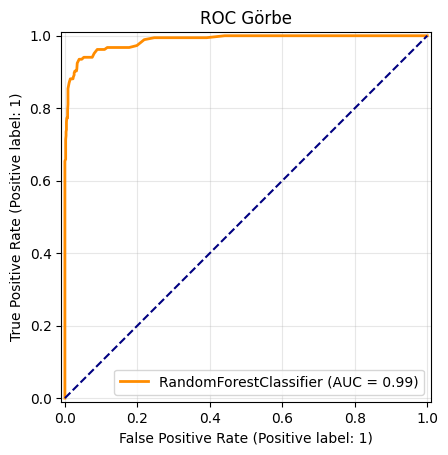

In [82]:
RocCurveDisplay.from_estimator(classifier, X_test, y_test, color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Görbe', fontsize=12)
plt.grid(alpha=0.3)

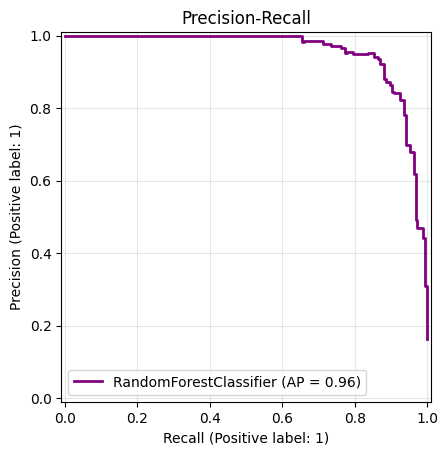

In [83]:
PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test,  color='purple', linewidth=2)
plt.title('Precision-Recall', fontsize=12)
plt.grid(alpha=0.3)

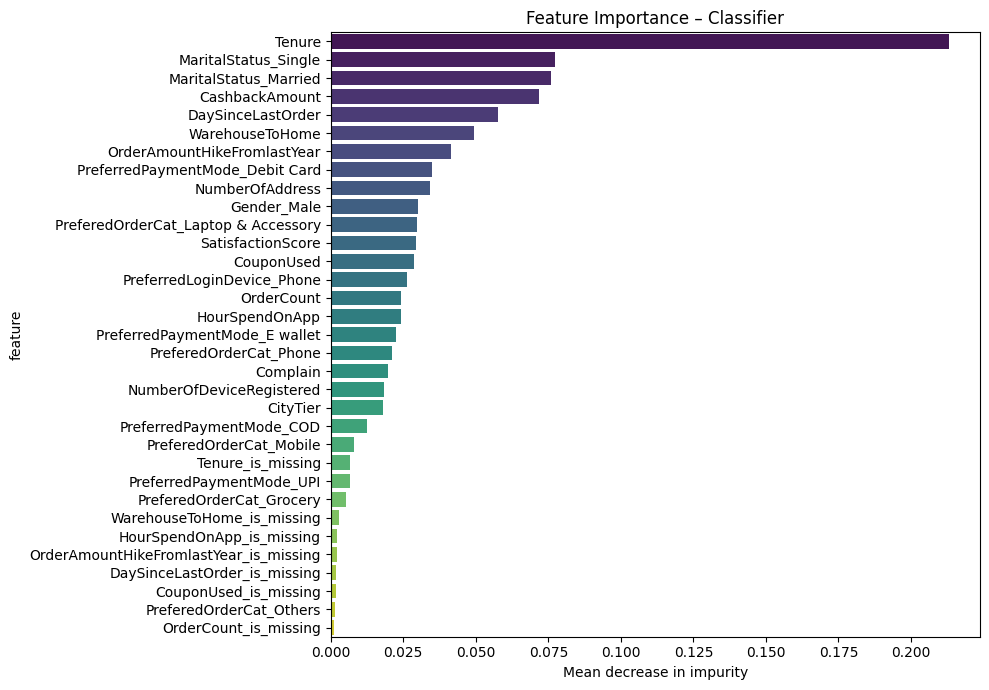

In [84]:

fi_df = (
    pd.DataFrame({'feature': X.columns, 'importance': classifier.feature_importances_})
    .sort_values('importance', ascending=False)
)
plt.figure(figsize=(10,7))
sns.barplot(data=fi_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – Classifier')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

In [85]:
gbc = joblib.load('models/GradientBoostingClassifier_model.pkl')

y_pred = gbc.predict(X_test)

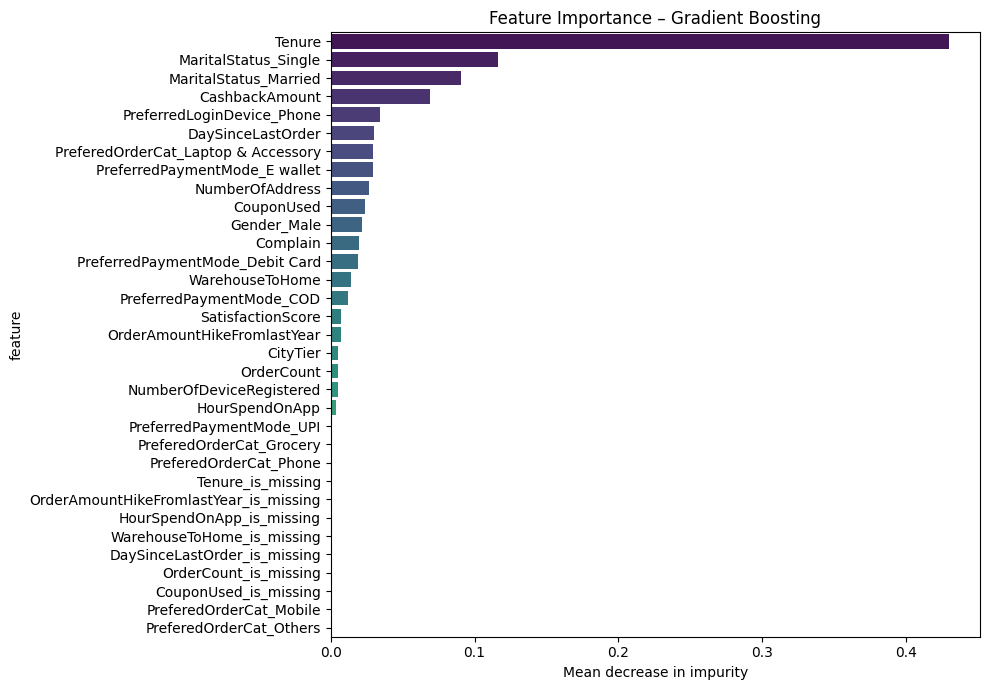

In [86]:
gbc_fi_df = (
    pd.DataFrame({'feature': X.columns, 'importance': gbc.feature_importances_})
    .sort_values('importance', ascending=False)
)
plt.figure(figsize=(10,7))
sns.barplot(data=gbc_fi_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – Gradient Boosting')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

In [87]:
log_reg = joblib.load('models/LogisticRegression_model.pkl')
coefficients = log_reg.coef_[0]

In [88]:
coef_df = pd.DataFrame({'Feature': X.columns,'Coefficient': coefficients})

In [89]:
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

<Axes: xlabel='Coefficient', ylabel='Feature'>

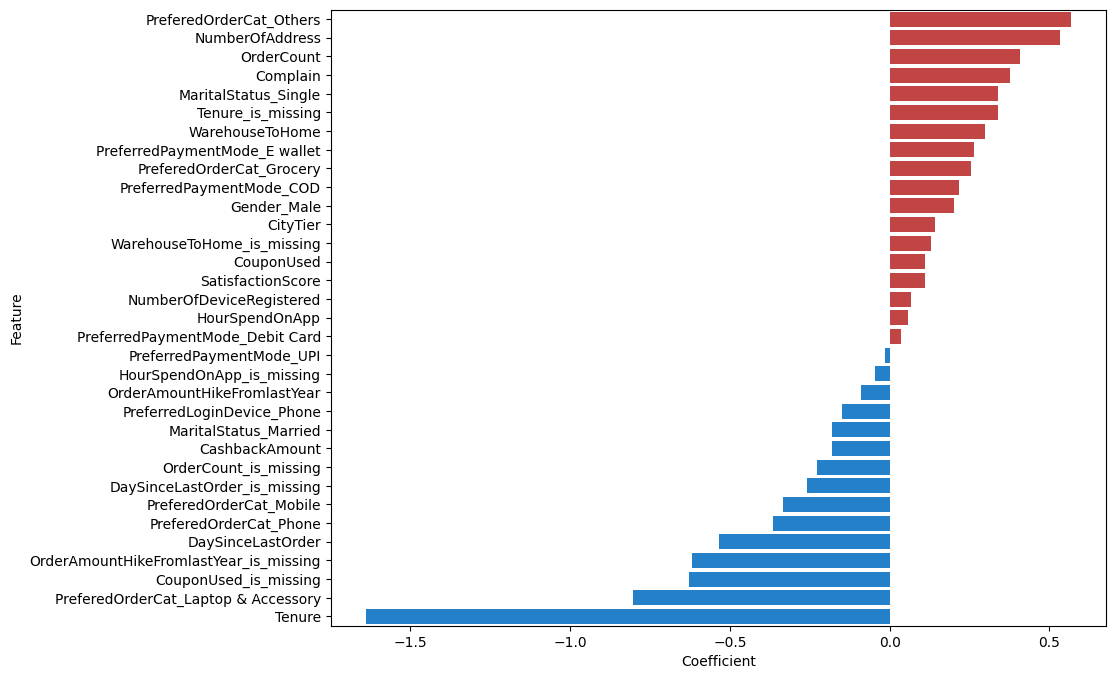

In [90]:
colors = ['#d63031' if c > 0 else '#0984e3' for c in coef_df['Coefficient']]
plt.figure(figsize=(10,8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature',hue='Feature', palette=colors)